# Notebook 3: Attention-Analyse
**Kurs:** Mechanistic Interpretability  
**Modell:** EleutherAI/pythia-410m  
**Ziel:** Attention-Muster visualisieren und wichtige Heads identifizieren.

> **Aufgabe:** Implementiere die Zellen schrittweise. Hilfreiche Dokumentation:
> - HuggingFace `output_attentions`: https://huggingface.co/docs/transformers/main_classes/output
> - Matplotlib Imshow: https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.imshow.html
> - NumPy argsort: https://numpy.org/doc/stable/reference/generated/numpy.argsort.html

## Hintergrund: Attention-Mechanismus

In jedem Transformer-Layer berechnen **Attention Heads** gewichtete Summen über alle Token-Positionen:

```
A = softmax( QK^T / sqrt(d_head) )
```

Die Attention-Matrix A hat die Form **(seq × seq)**:
- Zeile i: Welche Positionen achtet Position i?
- Spalte j: Von welchen Positionen wird Position j beachtet?

In der Mechanistic Interpretability fragen wir: **Welche Heads implementieren welche Funktion?**

Bekannte Head-Typen:
- **Previous Token Heads**: Achten auf das unmittelbar vorherige Token
- **Induction Heads**: Implementieren Muster-Vervollständigung ("A...B...A → B")
- **Name Mover Heads**: Transportieren semantische Information zur Ausgabe-Position

## 1. Setup und Modell laden

In [27]:
%load_ext autoreload
%autoreload 2

# Standard-library imports used only for notebook bootstrapping.
# The analysis logic itself lives in the utility modules imported below.
import sys
import importlib
from pathlib import Path
from IPython.display import Image, display

# Add the assignment utility directory to the import path.
utils_dir = Path.cwd().parent / "utils"
if not (utils_dir / "config.py").exists():
    raise FileNotFoundError(f"Could not find the assignment utils directory: {utils_dir}")

if str(utils_dir) not in sys.path:
    sys.path.insert(0, str(utils_dir))

# Reload utility modules so notebook reruns pick up local code changes.
import config
import model_utils
import plotting_utils
import attention_utils

for module in [config, model_utils, plotting_utils, attention_utils]:
    importlib.reload(module)

# Import high-level attention-analysis functions. Heavy computation and plotting
# stay in the utility files so the notebook remains readable.
from model_utils import load_model_and_tokenizer, setup_environment
from attention_utils import (
    analyze_induction_heads,
    analyze_subject_attention,
    print_attention_reflection,
    print_ranked_heads,
    run_attention_forward_pass,
    plot_selected_attention_heads,
)

# Select the available device and load the same model/tokenizer pair used in
# the rest of the assignment.
device = setup_environment()
model, tokenizer = load_model_and_tokenizer(device)

# Display helper for PNG files produced by plotting utilities.
def display_image(png_name):
    image_path = config.OUTPUT_PNG_DIR / png_name
    if not image_path.exists():
        raise FileNotFoundError(f"PNG image not found in output directory: {image_path}")
    display(Image(filename=str(image_path)))


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
PyTorch-Version : 2.6.0+cu124
Gerät           : cpu


Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]


Modell-Architektur:
GPTNeoXForCausalLM(
  (gpt_neox): GPTNeoXModel(
    (embed_in): Embedding(50304, 1024)
    (emb_dropout): Dropout(p=0.0, inplace=False)
    (layers): ModuleList(
      (0-23): 24 x GPTNeoXLayer(
        (input_layernorm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
        (post_attention_layernorm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
        (post_attention_dropout): Dropout(p=0.0, inplace=False)
        (post_mlp_dropout): Dropout(p=0.0, inplace=False)
        (attention): GPTNeoXAttention(
          (query_key_value): Linear(in_features=1024, out_features=3072, bias=True)
          (dense): Linear(in_features=1024, out_features=1024, bias=True)
        )
        (mlp): GPTNeoXMLP(
          (dense_h_to_4h): Linear(in_features=1024, out_features=4096, bias=True)
          (dense_4h_to_h): Linear(in_features=4096, out_features=1024, bias=True)
          (act): GELUActivation()
        )
      )
    )
    (final_layer_norm): LayerNorm

## 2. Forward Pass mit Attention-Gewichten

In [28]:
prompt = "The food was delicious and the service was"

# Run one forward pass with output_attentions=True and keep the decoded tokens
# plus all layer/head attention tensors for the following chapters.
attention_run = run_attention_forward_pass(model, tokenizer, device, prompt)
tokens = attention_run["tokens"]
attentions = attention_run["attentions"]


Prompt tokens (8):
 0: 'The'
 1: ' food'
 2: ' was'
 3: ' delicious'
 4: ' and'
 5: ' the'
 6: ' service'
 7: ' was'

Attention tensors:
Number of attention matrices: 24
outputs.attentions is a tuple with 24 entries.
One tuple entry is returned per transformer layer.
Single head attention matrix size: (8, 8)
Layer 0: (1, 16, 8, 8)
Layer 1: (1, 16, 8, 8)
Layer 2: (1, 16, 8, 8)
Layer 3: (1, 16, 8, 8)
Layer 4: (1, 16, 8, 8)
Layer 5: (1, 16, 8, 8)
Layer 6: (1, 16, 8, 8)
Layer 7: (1, 16, 8, 8)
Layer 8: (1, 16, 8, 8)
Layer 9: (1, 16, 8, 8)
Layer 10: (1, 16, 8, 8)
Layer 11: (1, 16, 8, 8)
Layer 12: (1, 16, 8, 8)
Layer 13: (1, 16, 8, 8)
Layer 14: (1, 16, 8, 8)
Layer 15: (1, 16, 8, 8)
Layer 16: (1, 16, 8, 8)
Layer 17: (1, 16, 8, 8)
Layer 18: (1, 16, 8, 8)
Layer 19: (1, 16, 8, 8)
Layer 20: (1, 16, 8, 8)
Layer 21: (1, 16, 8, 8)
Layer 22: (1, 16, 8, 8)
Layer 23: (1, 16, 8, 8)


### Ergebnisinterpretation

Hier wurde der Prompt tokenisiert und anschließend ein Forward Pass durch das Modell ausgeführt, diesmal mit `output_attentions=True`. Dadurch gibt das Modell nicht nur die normalen Logits zurück, sondern zusätzlich die Attention-Tensoren aller Transformer-Schichten.

Die Ausgabe beginnt mit den Prompt-Tokens. Da die Tokens jetzt mit `tokenizer.decode([token_id])` erzeugt werden, erscheinen Leerzeichen als normale Leerzeichen im Token-Text und nicht mehr als interne Tokenizer-Markierungen wie `Ġ`.

Die Zeile:

```text
Number of attention matrices: 24
```

bedeutet, dass `outputs.attentions` 24 Attention-Einträge enthält. Das passt zur Architektur von Pythia-410M: Das Modell hat 24 Transformer-Schichten, und für jede Schicht wird genau ein Attention-Tensor zurückgegeben.

Die Zeile:

```text
outputs.attentions is a tuple with 24 entries.
```

macht explizit, dass `outputs.attentions` kein einzelner Tensor ist, sondern ein Tupel mit 24 Elementen. Jedes Element dieses Tupels gehört zu einer Transformer-Schicht.

Die Zeile:

```text
Single head attention matrix size: (8, 8)
```

beschreibt die Größe einer einzelnen Attention-Matrix für einen einzelnen Head. In diesem Beispiel besteht der Prompt aus 8 Tokens, daher hat die Matrix die Form `8 x 8`. Jede Zeile steht für eine Query-Position, also das Token, das Aufmerksamkeit verteilt. Jede Spalte steht für eine Key-Position, also ein Token, auf das geachtet werden kann.

Eine Layer-Ausgabe wie:

```text
Layer 8: (1, 16, 8, 8)
```

bedeutet konkret:

```text
(batch_size, number_of_heads, query_positions, key_positions)
```

Für dieses Beispiel heißt das:

- `1`: Es wurde genau ein Prompt gleichzeitig verarbeitet.
- `16`: Jede Schicht besitzt 16 Attention Heads.
- `8`: Der Prompt besteht aus 8 Query-Positionen.
- `8`: Der Prompt besteht aus 8 Key-Positionen.

Da das Modell kausal arbeitet, dürfen Tokens nicht auf zukünftige Tokens achten. Die Attention-Matrix enthält daher vor allem Aufmerksamkeit auf vorherige oder aktuelle Token-Positionen. Diese Attention-Tensoren bilden die Grundlage für die nächsten Kapitel, in denen einzelne Heads visualisiert und danach systematisch nach starken Subject-Attention- oder Induction-Mustern durchsucht werden.


## 3. Einzelne Attention-Heads visualisieren

Saved file: attention_head_grid.png


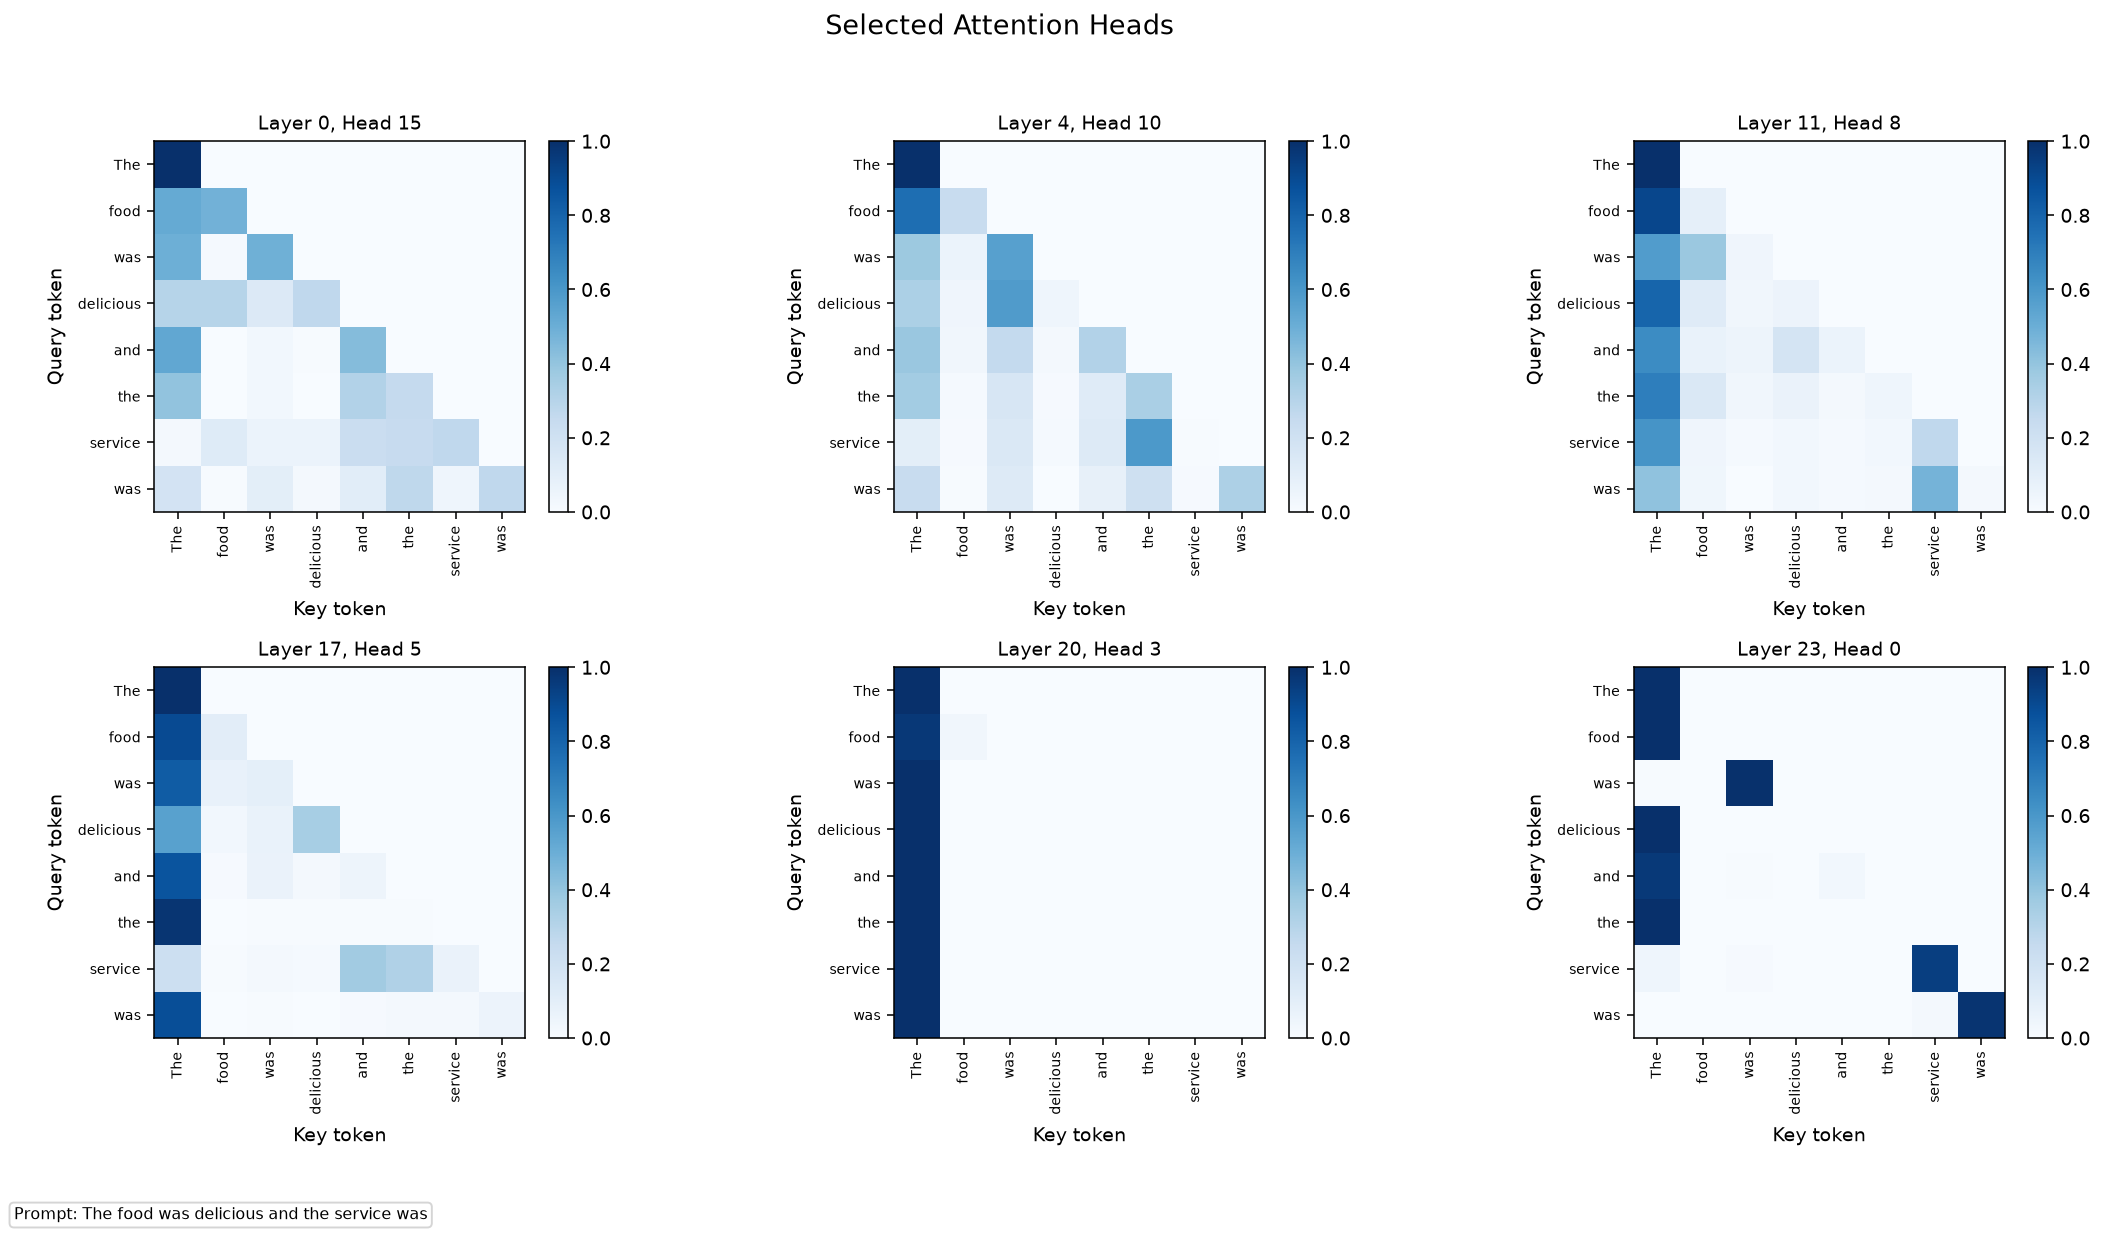

In [31]:
# Choose the layer/head pairs to inspect in the attention-head grid.
heads_to_plot = [
    (0, 15),
    (4, 10),
    (11, 8),
    (17, 5),
    (20, 3),
    (23, 0),
]

# Save and display the selected attention heads.
plot_selected_attention_heads(attentions, tokens, prompt, head_specs=heads_to_plot)
display_image(config.ATTENTION_HEAD_GRID_PATH.name)


## 4. Attention auf Subject-Token

In [33]:
# Measure how strongly the final token attends to the subject token across all heads.
subject_attention_result = analyze_subject_attention(
    attentions,
    tokens,
    subject_token=" delicious",
    top_k=10,
    filename_or_path=config.ATTENTION_SUBJECT_HEATMAP_PATH,
)
att_to_subject = subject_attention_result["attention_values"]


Subject token ' delicious' found at position 3.
Rank   Layer   Head   Attention
--------------------------------------
1      6       3      0.835123
2      10      13     0.500263
3      0       13     0.371467
4      7       7      0.358672
5      8       7      0.353302
6      19      15     0.349163
7      4       7      0.317502
8      3       15     0.297037
9      12      0      0.274218
10     7       3      0.271510
Saved file: attention_subject_heatmap.png


## 5. Heatmap: Alle Heads und Layers

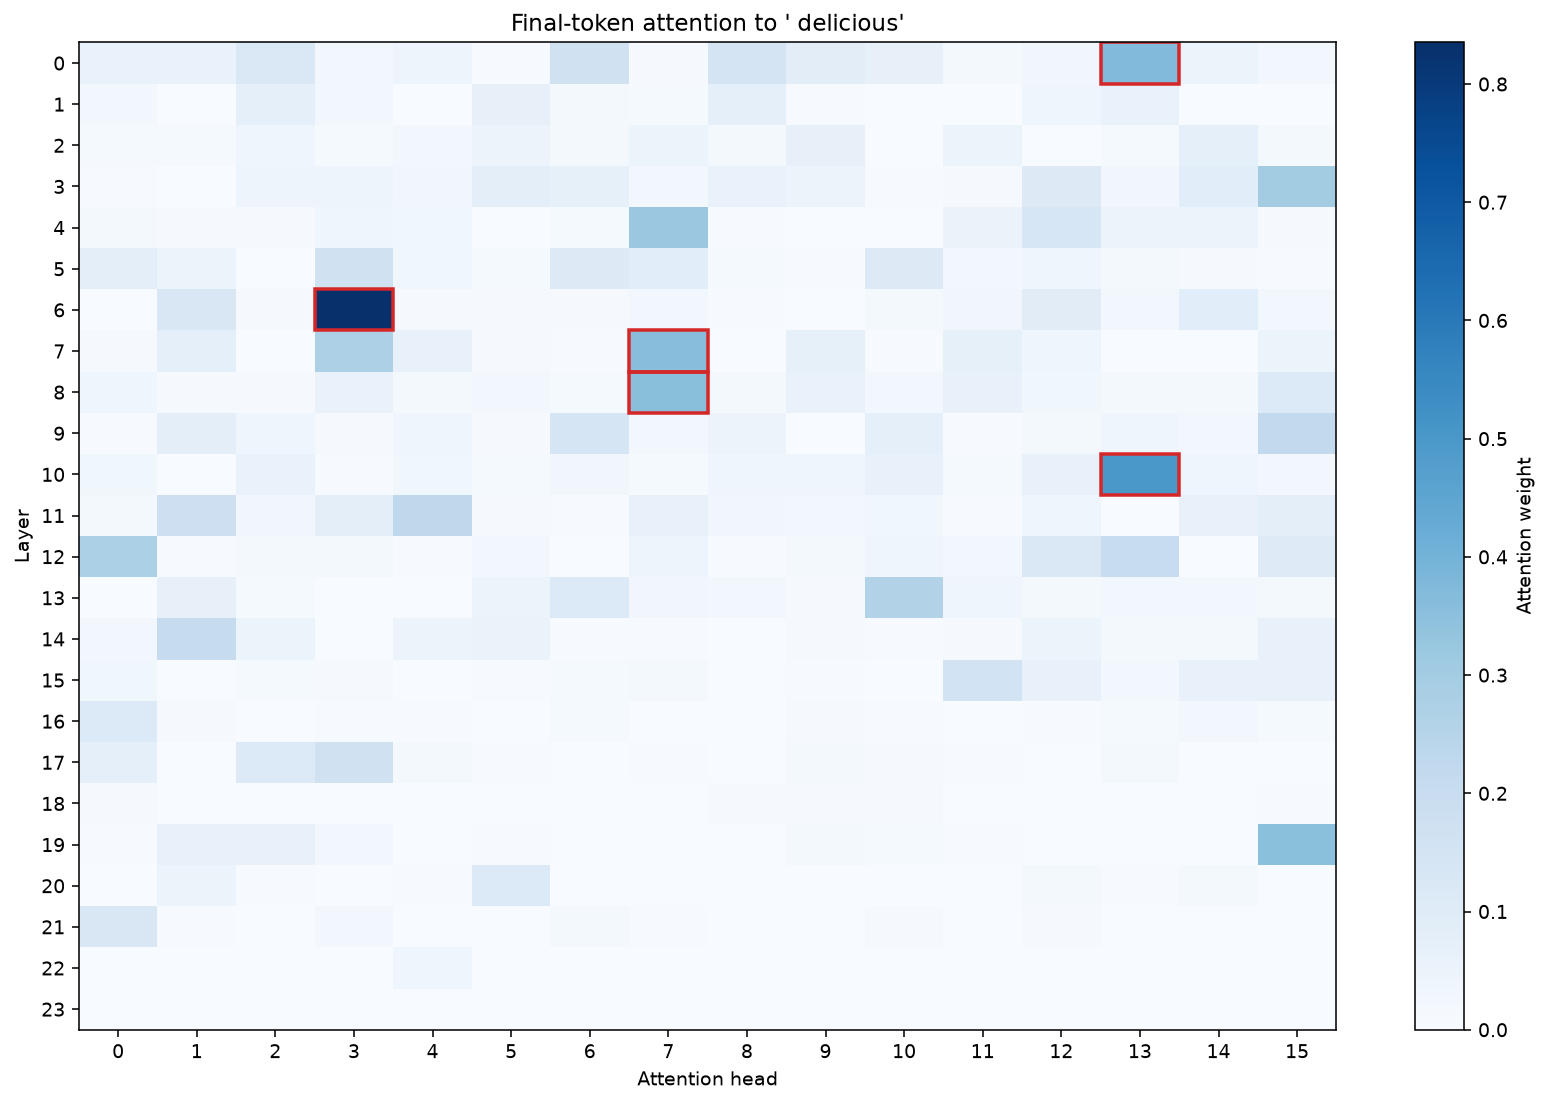

In [34]:
# Display the layer/head heatmap generated by the subject-attention analysis.
# The outlined cells mark the five heads with the highest attention to France.
display_image(config.ATTENTION_SUBJECT_HEATMAP_PATH.name)


## 6. Top-Heads-Rangliste

In [35]:
# Print the top-10 layer/head pairs ranked by final-token attention to France.
print_ranked_heads(subject_attention_result["ranked_heads"], score_label="Attention")


Rank   Layer   Head   Attention
--------------------------------------
1      6       3      0.835123
2      10      13     0.500263
3      0       13     0.371467
4      7       7      0.358672
5      8       7      0.353302
6      19      15     0.349163
7      4       7      0.317502
8      3       15     0.297037
9      12      0      0.274218
10     7       3      0.271510


## 7. BONUS: Induction Heads suchen

Rank   Layer   Head   Induction score
--------------------------------------
1      5       2      0.443560
2      4       9      0.424863
3      1       14     0.404122
4      3       9      0.398479
5      5       11     0.380464
6      3       1      0.372651
7      1       11     0.365844
8      22      14     0.364238
9      5       4      0.363464
10     5       9      0.355922
Highest induction score: layer 5, head 2 (0.443560)
Saved file: attention_induction_heatmap.png


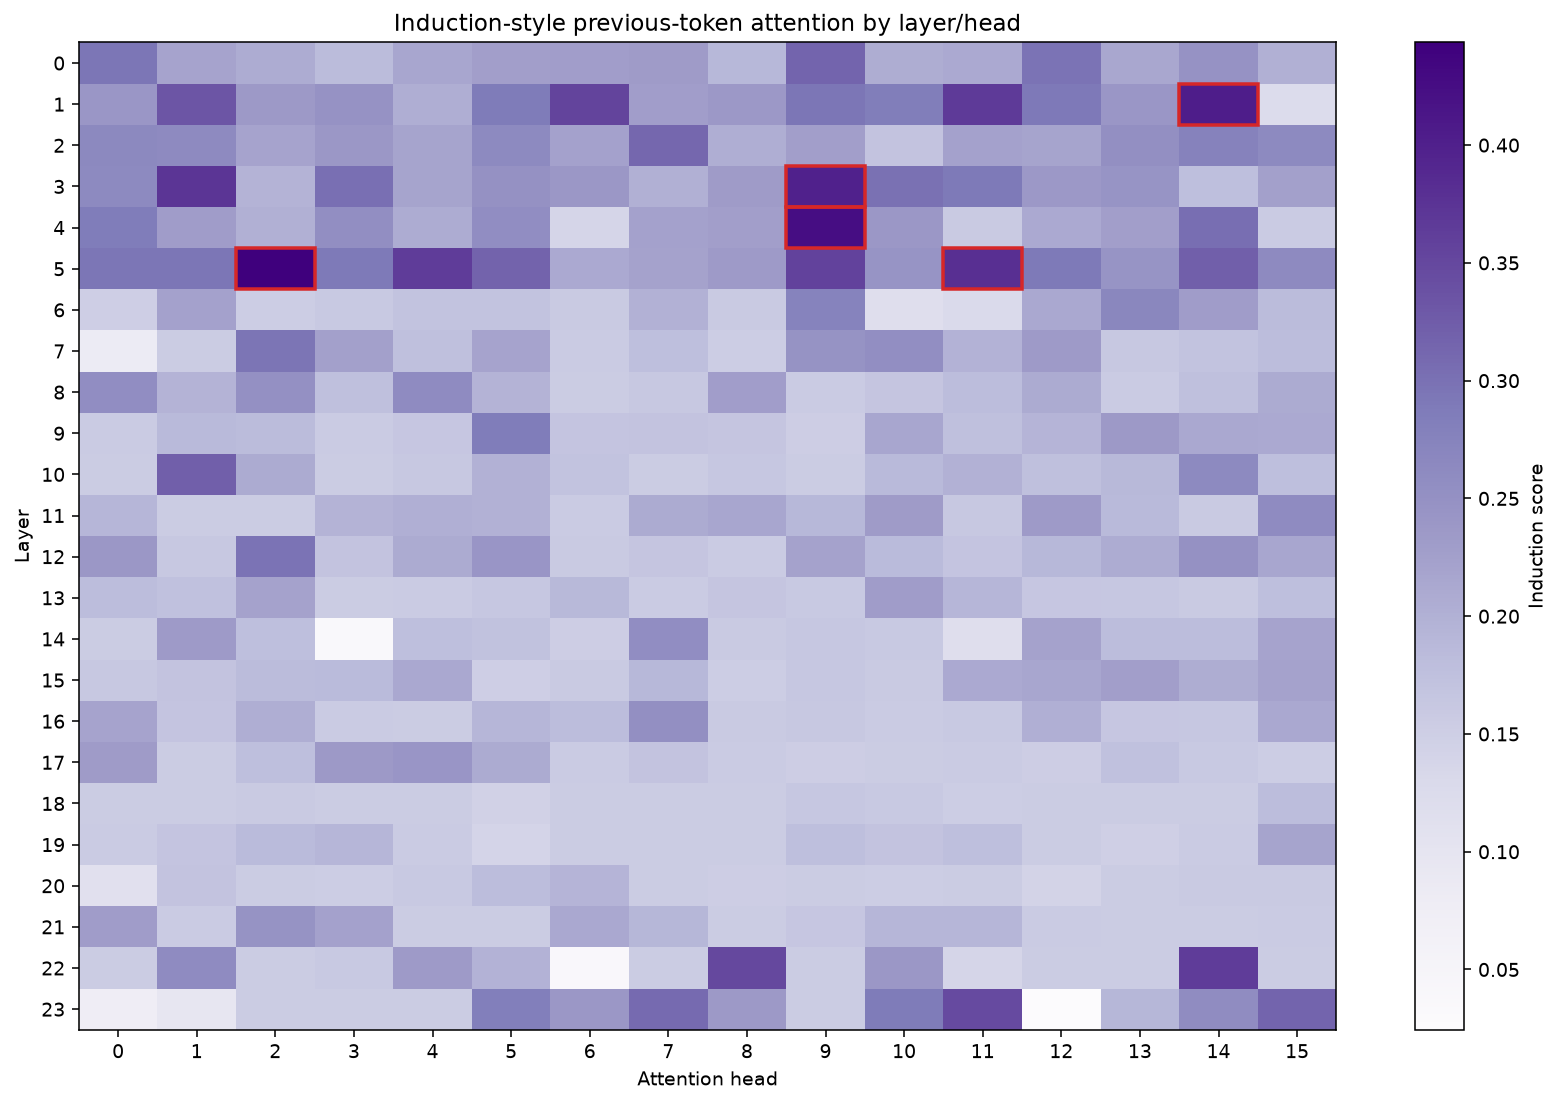

In [36]:
# Score each head by how much attention it places on previous-token diagonals.
# This is a simple induction-style proxy, not a causal proof of induction behavior.
induction_result = analyze_induction_heads(
    attentions,
    top_k=10,
    filename_or_path=config.ATTENTION_INDUCTION_HEATMAP_PATH,
)
display_image(config.ATTENTION_INDUCTION_HEATMAP_PATH.name)


## 8. Reflexionsfragen

In [37]:
# Print concise answers based on the computed subject-attention and induction rankings.
print_attention_reflection(subject_attention_result, induction_result)


1. Strongest subject-attention head:
   Layer 6, head 3.
2. Strongest subject-attention layer range:
   Top heads occur in layers: [0, 6, 7, 8, 10].
3. Why attention analysis alone is not causal:
   High attention shows information flow patterns, but not whether the head is necessary for the output.
4. Difference to activation patching:
   Activation patching intervenes on activations and measures output changes, so it tests causal effect.
5. Strongest induction-style head:
   Layer 5, head 2.
